In [ ]:
import pandas as pd

df = pd.read_csv("deceptive-opinion.csv")
df.head()

,deceptive,hotel,polarity,source,text
0,truthful,conrad,positive,TripAdvisor,We stayed for a one night getaway with family ...
1,truthful,hyatt,positive,TripAdvisor,Triple A rate with upgrade to view room was le...
2,truthful,hyatt,positive,TripAdvisor,This comes a little late as I'm finally catchi...
3,truthful,omni,positive,TripAdvisor,The Omni Chicago really delivers on all fronts...
4,truthful,hyatt,positive,TripAdvisor,I asked for a high floor away from the elevato...


In [ ]:
df = df[["text", "deceptive"]]

df = df.rename(columns={
    "text": "review",
    "deceptive": "label"
})

df["label"] = df["label"].map({
    "truthful": 0,
    "deceptive": 1
})

df["review"] = df["review"].astype(str)
df["review"] = df["review"].str.strip()
df["review"] = df["review"].str.replace(r"\s+", " ", regex=True)

df = df.dropna()
df = df.drop_duplicates()

print(df.info())
print(df["label"].value_counts())

<class 'pandas.DataFrame'>
Index: 1596 entries, 0 to 1599
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   review  1596 non-null   str  
 1   label   1596 non-null   int64
dtypes: int64(1), str(1)
memory usage: 1.3 MB
None
label
1    800
0    796
Name: count, dtype: int64


In [ ]:
from sklearn.model_selection import train_test_split

train_texts, temp_texts, train_labels, temp_labels = train_test_split(
    df['review'],
    df['label'],
    test_size=0.3,
    stratify=df["label"],
    random_state=42
)

val_texts, test_texts, val_labels, test_labels = train_test_split(
    temp_texts,
    temp_labels,
    test_size=0.5,
    stratify=temp_labels,
    random_state=42
)

In [ ]:
from transformers import RobertaTokenizer

tokenizer = RobertaTokenizer.from_pretrained("roberta-base")

train_encodings = tokenizer(list(train_texts), truncation=True, padding=True)
val_encodings = tokenizer(list(val_texts), truncation=True, padding=True)
test_encodings = tokenizer(list(test_texts), truncation=True, padding=True)

c:\ML_in_Cyber\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [ ]:
import torch

class ReviewDataset(torch.utils.data.Dataset):
  def __init__(self, encodings, labels):
    self.encodings = encodings
    self.labels = list(labels)

  def __getitem__(self, idx):
    item = {key: torch.tensor(val[idx]) for key, val in self.encodings.items()}
    item['labels'] = torch.tensor(self.labels[idx])
    return item

  def __len__(self):
    return len(self.labels)

train_dataset = ReviewDataset(train_encodings, train_labels)
val_dataset = ReviewDataset(val_encodings, val_labels)
test_dataset = ReviewDataset(test_encodings, test_labels)

In [ ]:
from transformers import RobertaForSequenceClassification

model = RobertaForSequenceClassification.from_pretrained("roberta-base", num_labels=2)

Loading weights: 100%|██████████| 197/197 [00:00<00:00, 4253.60it/s]
[transformers] RobertaForSequenceClassification LOAD REPORT from: roberta-base
Key                        | Status     | 
---------------------------+------------+-
lm_head.bias               | UNEXPECTED | 
lm_head.layer_norm.bias    | UNEXPECTED | 
lm_head.layer_norm.weight  | UNEXPECTED | 
lm_head.dense.bias         | UNEXPECTED | 
lm_head.dense.weight       | UNEXPECTED | 
classifier.out_proj.weight | MISSING    | 
classifier.dense.bias      | MISSING    | 
classifier.dense.weight    | MISSING    | 
classifier.out_proj.bias   | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [ ]:
from transformers import TrainingArguments

training_args = TrainingArguments(
    output_dir="./results",
    eval_strategy="epoch",
    learning_rate=2e-5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    num_train_epochs=10,
    weight_decay=0.01,
    logging_strategy="epoch",
    report_to="none"
)

In [ ]:
from transformers import Trainer

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset
)

trainer.train()

Epoch,Training Loss,Validation Loss
1,0.629155,0.786385
2,0.357621,0.468623
3,0.291540,0.276377
4,0.169642,0.539395
5,0.132969,0.423466
6,0.032422,0.512104
7,0.036985,0.551574
8,0.011929,0.569949
9,0.010905,0.606949
10,0.002302,0.599059


Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  2.58it/s]


TrainOutput(global_step=700, training_loss=0.16754717371293476, metrics={'train_runtime': 3211.3481, 'train_samples_per_second': 3.478, 'train_steps_per_second': 0.218, 'total_flos': 2938950488371200.0, 'train_loss': 0.16754717371293476, 'epoch': 10.0})

In [ ]:
results = trainer.evaluate(test_dataset)
print(results)

Training Loss,Validation Loss,Epoch
0.002302,0.732744,10


{'eval_loss': 0.732743501663208}


In [ ]:
from sklearn.metrics import classification_report, confusion_matrix

preds = trainer.predict(test_dataset)
y_pred = preds.predictions.argmax(axis=1)
y_true = preds.label_ids

print(classification_report(y_true, y_pred))
print(confusion_matrix(y_true, y_pred))

              precision    recall  f1-score   support

           0       0.95      0.84      0.89       120
           1       0.86      0.96      0.91       120

    accuracy                           0.90       240
   macro avg       0.91      0.90      0.90       240
weighted avg       0.91      0.90      0.90       240

[[101  19]
 [  5 115]]


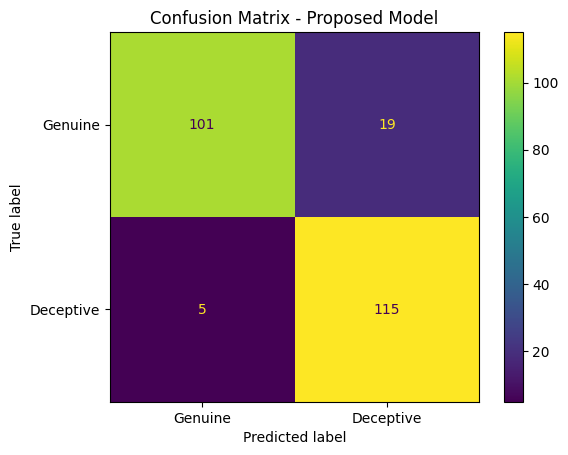

In [ ]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

ConfusionMatrixDisplay.from_predictions(
    y_true,
    y_pred,
    display_labels=["Genuine", "Deceptive"]
)

plt.title("Confusion Matrix - Proposed Model")
plt.show()

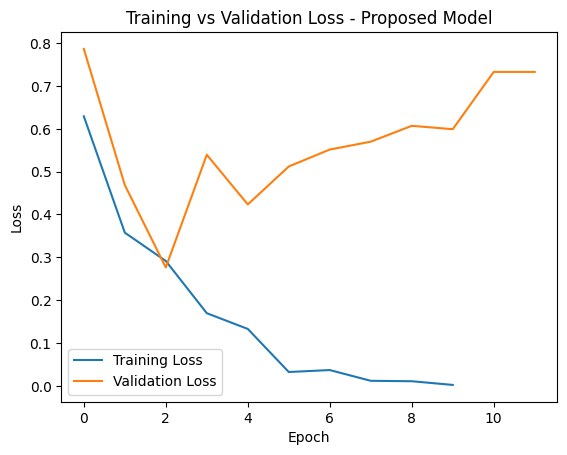

In [ ]:
logs = trainer.state.log_history

train_loss = [x["loss"] for x in logs if "loss" in x]
eval_loss = [x["eval_loss"] for x in logs if "eval_loss" in x]

plt.plot(train_loss, label="Training Loss")
plt.plot(eval_loss, label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss - Baseline Model")
plt.legend()
plt.show()